# 5. Основное обучение и сравнение моделей

Ноутбук читает завершённые эксперименты: сначала исходное разбиение архива, затем общий test на новых публикующих каналах. Все настройки, истории и предсказания сохранены в `outputs/`; обучение реализовано отдельно в `scripts/train_vk_bundle.py`.

Использовались AdamW, seed 42 и предобученные веса. В основных DINOv2 encoder заморожен, учатся головы. ResNet-18, X3D и R3D дообучаются целиком. В partial-DINOv2 дополнительно настраиваются два последних блока и завершающий LayerNorm. Это сравнение рабочих конфигураций с разными кадрами, batch и режимами настройки.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "scripts/train_vk_bundle.py").is_file()
             and (p / "configs/experiment_index.csv").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Запустите ноутбук внутри sports_video_repo")

def load_json(path):
    return json.loads((ROOT / path).read_text(encoding="utf-8"))

def load_jsonl(path):
    return [json.loads(line) for line in (ROOT / path).read_text(encoding="utf-8").splitlines() if line]

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True})
print("Читаем сохранённые результаты; обучение и скачивание не запускаются.")

Читаем сохранённые результаты; обучение и скачивание не запускаются.


## Параметры и выбор лучшей эпохи

In [2]:
runs = ["vk_owner_resnet18_1f", "vk_owner_dinov2_1f", "vk_owner_dinov2_1f_weighted",
        "vk_owner_dinov2_4f", "vk_owner_dinov2_partial_4f",
        "vk_owner_x3d_shortside_4f", "vk_owner_r3d18_16f"]
settings = []
for run in runs:
    cfg, hist = load_json(f"outputs/{run}/config.json"), load_json(f"outputs/{run}/history.json")
    best = max(hist, key=lambda x: x["val_mean_macro_f1"])
    mode = "последние 2 блока + LayerNorm + головы" if cfg.get("unfreeze_last_blocks") else (
        "только головы" if cfg["freeze"] else "вся модель")
    settings.append({"запуск": run, "кадров": cfg["frames"], "обучаются": mode,
        "эпох выполнено": len(hist), "batch": cfg["batch_size"], "lr": cfg["lr"],
        "lr голов": cfg.get("head_lr"), "лучшая эпоха": best["epoch"]})
display(pd.DataFrame(settings))

,запуск,кадров,обучаются,эпох выполнено,batch,lr,lr голов,лучшая эпоха
0,vk_owner_resnet18_1f,1,вся модель,8,16,0.000100,NaN,6
1,vk_owner_dinov2_1f,1,только головы,8,16,0.001000,NaN,7
2,vk_owner_dinov2_1f_weighted,1,только головы,8,16,0.001000,NaN,7
3,vk_owner_dinov2_4f,4,только головы,8,8,0.001000,NaN,8
4,vk_owner_dinov2_partial_4f,4,последние 2 блока + LayerNorm + головы,5,2,0.000002,0.00005,5
5,vk_owner_x3d_shortside_4f,4,вся модель,6,4,0.000200,NaN,5
6,vk_owner_r3d18_16f,16,вся модель,5,2,0.000200,NaN,5


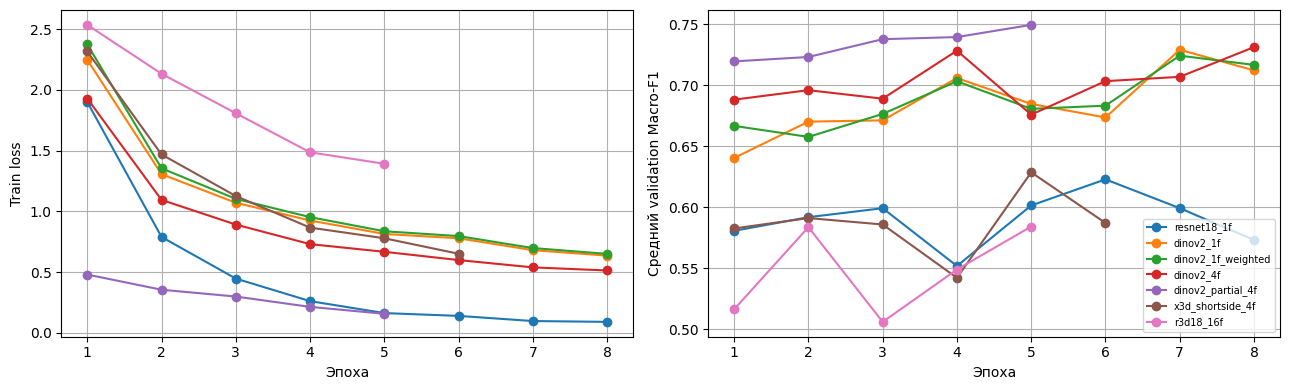

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for run in runs:
    hist = pd.DataFrame(load_json(f"outputs/{run}/history.json"))
    label = run.replace("vk_owner_", "")
    axes[0].plot(hist.epoch, hist.train_loss, marker="o", label=label)
    axes[1].plot(hist.epoch, hist.val_mean_macro_f1, marker="o", label=label)
axes[0].set(xlabel="Эпоха", ylabel="Train loss")
axes[1].set(xlabel="Эпоха", ylabel="Средний validation Macro-F1")
axes[1].legend(fontsize=7); plt.tight_layout(); plt.show()

## Итоговый test: 61 группа, 165 окон, 23 новых канала

In [4]:
scores = []
for run in runs:
    met = load_json(f"outputs/{run}/test_metrics.json")["group"]
    scores.append({"запуск": run, "спорт": met["sport"]["macro_f1"],
                   "пол": met["gender"]["macro_f1"], "возраст": met["age"]["macro_f1"],
                   "все три": met["all_three_accuracy"]})
display(pd.DataFrame(scores).round(3))

,запуск,спорт,пол,возраст,все три
0,vk_owner_resnet18_1f,0.732,0.622,0.852,0.459
1,vk_owner_dinov2_1f,0.884,0.670,0.769,0.525
2,vk_owner_dinov2_1f_weighted,0.865,0.688,0.785,0.525
3,vk_owner_dinov2_4f,0.930,0.639,0.689,0.475
4,vk_owner_dinov2_partial_4f,0.908,0.652,0.689,0.492
5,vk_owner_x3d_shortside_4f,0.832,0.666,0.801,0.508
6,vk_owner_r3d18_16f,0.824,0.568,0.593,0.377


## Исходное разбиение и вспомогательные варианты

In [5]:
original = load_json("outputs/vk_comparison.json")
display(pd.DataFrame(original["summary"]).T[["sport_macro_f1", "gender_macro_f1", "age_macro_f1", "all_three_accuracy"]].round(3))
owner_comparison = load_json("outputs/vk_owner_comparison.json")
print("Bootstrap повторов:", owner_comparison["bootstrap_replicates"])
print("Ключи парных сравнений:", list(owner_comparison["paired_comparisons"]))
display(pd.DataFrame(owner_comparison["paired_comparisons"]["DINOv2-S 4f minus DINOv2-S 1f"]).T)

,sport_macro_f1,gender_macro_f1,age_macro_f1,all_three_accuracy
DINOv2-S 1f,0.932,0.698,0.896,0.657
DINOv2-S 4f,0.953,0.710,0.880,0.627
DINOv2-S 8f,0.953,0.712,0.880,0.627
DINOv2-S partial 4f,0.977,0.755,0.925,0.701
X3D-XS 4f,0.874,0.730,0.880,0.657
X3D-XS shortside 4f,0.872,0.731,0.910,0.657
R3D-18 16f,0.782,0.551,0.895,0.448


Bootstrap повторов: 5000
Ключи парных сравнений: ['DINOv2-S 4f minus ResNet-18 1f', 'DINOv2-S 4f minus DINOv2-S 1f', 'DINOv2-S 4f minus DINOv2-S 1f weighted', 'DINOv2-S 4f minus DINOv2-S partial 4f', 'DINOv2-S 4f minus X3D-XS 4f', 'DINOv2-S 4f minus X3D-XS shortside 4f', 'DINOv2-S 4f minus R3D-18 16f', 'DINOv2-S 1f minus ResNet-18 1f', 'DINOv2-S 1f weighted minus DINOv2-S 1f', 'X3D-XS shortside 4f minus DINOv2-S 1f']


,difference,paired_bootstrap_95pct
sport,0.045278,"[-0.02248363612508357, 0.12316873842088379]"
gender,-0.030666,"[-0.12725171632923277, 0.06949428225047911]"
age,-0.080415,"[-0.1547656735887989, -0.01634056054997357]"


DINOv2 4f лидирует по виду спорта, а DINOv2 1f лучше по полному совпадению трёх меток на этом тесте. Веса классов немного меняют пол и возраст, но не улучшают долю полностью верных ответов. Частичная настройка DINOv2 помогала на исходном split, однако не повторила такой выигрыш на новых каналах. Основной кандидат для трёх меток — DINOv2 1f; ResNet-18 полезен как быстрый baseline.

Парный bootstrap рассчитывался отдельным скриптом `compare_vk_bundle.py`; здесь показаны уже сохранённые интервалы. Дополнительный X3D с равномерными четырьмя кадрами и технические probe сохранены отдельно. Итоговый X3D в таблице — `shortside182`, он отличается временным семплингом и пространственной подготовкой.

[Результаты](../docs/results/VK_BUNDLE_RESULTS.md), [команды всех сохранённых обучений](../docs/EXPERIMENT_COMMANDS.md).